# ShakerMaker

**SFSI benchmark case study** -- Samoa Beach, Humboldt County, California.

This notebook documents the full ShakerMaker workflow for synthesising
seismograms at a site of interest: the station geometry and the source are
defined, a layered crustal model is assembled, the numerical FK parameters are
checked, and the simulation is run. The resulting time series are then retrieved,
converted to velocity and acceleration, and used to build an elastic response
spectrum (Newmark SDOF integration).

Each code block is preceded by a short heading and explanation describing what
that block does. Nothing has been invented -- every explanation reflects the code
that follows it.

---

## 1. Environment

Numerical and plotting libraries, plus the ShakerMaker package, which provides
the FK synthesis engine, the crustal models, the sources, the source-time
functions (STFs) and the station infrastructure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### ShakerMaker imports

Modules used throughout the notebook:

- `shakermaker` -- the engine (the `ShakerMaker` class and its `run` method).
- `CrustModel` -- the layered crustal model.
- `PointSource` / `FaultSource` -- a point source and its fault container.
- `Gaussian` -- the Gaussian source-time function (STF).
- `Station` / `StationList` -- receiver stations and their collection.

In [2]:
# Core
from shakermaker import shakermaker
# Crust model
from shakermaker.crustmodel import CrustModel
# Source
from shakermaker.pointsource import PointSource
from shakermaker.faultsource import FaultSource
# STF
from shakermaker.stf_extensions.gaussian import Gaussian

# Station
from shakermaker.station import Station
from shakermaker.stationlist import StationList


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

## 2. Station geometry

UTM 10N coordinates (in metres) of the sites of interest, together with their
names. These are the stations where ground motions are required. Coordinates are
kept in UTM because the project works in that frame; they are converted to WGS84
only for the map and to kilometres for ShakerMaker.

In [3]:
# Station coordinates (UTM)

utmx = np.array([
    405811.5368, 405964.3274, 406557.2285, 406426.7430, 406280.7166,
    405977.8081, 405127.1656, 405668.1475, 404622.1449, 409033.3607,
    407839.3333, 408723.1503, 403610.9892, 402302.4274, 402902.2053,
    401993.5796, 402018.3799, 401095.9612, 400727.0942, 398358.9065,
    396758.8127, 397603.6277, 403615.2897, 402629.1866, 401966.8675,
    400353.3506, 399642.4017, 401525.3814, 405454.8196, 400619.7621,
    400938.7643, 399723.3834, 394699.6510, 397093.9913, 397250.1158,
    396922.4553, 397460.4121, 396713.3378, 385160.5117, 396580.2275,
    395804.8655, 409884.0883, 407904.1925, 407927.0648, 407807.8240,
    408134.8808, 408758.8132, 409155.2322, 413697.5278,
])

utmy = np.array([
    4543767.5139, 4543383.8271, 4542594.1469, 4540734.9324, 4538861.2662,
    4536548.2666, 4532902.9715, 4530797.5603, 4531522.5129, 4530264.8118,
    4523392.8364, 4519997.5509, 4517635.8541, 4523962.3467, 4525257.4723,
    4523550.5246, 4522961.0724, 4522217.3703, 4520957.5788, 4517172.5535,
    4513518.6022, 4514187.7071, 4517780.8973, 4518072.6088, 4518054.3808,
    4519457.3798, 4519533.3956, 4517869.6110, 4516622.4532, 4517527.6550,
    4517735.5514, 4516205.7360, 4509963.0737, 4510585.8559, 4510827.7328,
    4509102.5527, 4505470.2236, 4503633.9505, 4456319.0643, 4446890.6842,
    4447048.4264, 4437532.3723, 4433610.7015, 4432661.0598, 4431644.9821,
    4431457.9654, 4430819.4681, 4431103.9011, 4428122.6967,
])

utm_order = [
    "Luffenholtz Beach and County Park", "Houda Point Access", "Moonstone County Park", "Little River State Beach", "Clam Beach County Park",
    "McKinleyville Vista Point", "Mad River Bluffs Park", "Hammond Trail", "Mad River Beach County Park", "Azalea State Reserve",
    "Arcata Marsh and Wildlife Sanctuary", "Eureka KOA", "Ebb Tide R.V. Park", "Ma-Le'l Dunes South", "Ma-Le'l Dunes North",
    "Humboldt Coastal Nature Center", "Manila Community Park", "Manila Dunes Recreation Area", "North Spit", "Accessways to Ocean Beach",
    "Samoa Dunes Recreation Area", "Samoa Boat Ramp County Park", "Eureka Slough Boat Ramp", "Samoa Bridge Launching Facility", "Woodley Island Marina",
    "Humboldt Bay Maritime Museum", "Samoa Beach", "Eureka Boardwalk", "Eureka Slough / Dead Mouse Marsh", "Eureka Public Marina and Wharfinger Building",
    "Eureka Mooring Basin", "Del Norte Street Pier", "Mike Thompson Wildlife Area / South Spit", "King Salmon", "King Salmon Shoreline Access",
    "Fields Landing County Park", "Humboldt Bay National Wildlife Refuge", "Hookton Slough", "Punta Gorda Lighthouse", "King Range National Conservation Area (Humboldt)",
    "Lost Coast Trail", "Tolkan Campground", "Black Sands Beach", "Little Black Sands Beach", "Abalone Point",
    "Seal Rock", "Mal Coombs Park", "Shelter Cove", "King Range National Conservation Area (Mendocino)",
]


### Site map

UTM 10N is converted to WGS84 so the stations and the source can be plotted on an
interactive folium map. The source is shown in red and the stations in blue. The
map is a sanity check that the geometry and the coordinate convention are
consistent before the model is assembled.

> `always_xy=True` is used, so the transform returns `(lon, lat)` in that order.

In [4]:
import folium
from pyproj import Transformer

# UTM 10N -> WGS84
transformer = Transformer.from_crs("EPSG:32610", "EPSG:4326", always_xy=True)

# stations
lons, lats = transformer.transform(utmx, utmy)
# source
x_source, y_source = 491222.3167 , 4512564.5625


lon_s, lat_s = transformer.transform(x_source, y_source)
print(lon_s, lat_s)
# centered map
all_lats = list(lats) + [lat_s]
all_lons = list(lons) + [lon_s]
m = folium.Map(
    location=[sum(all_lats)/len(all_lats), sum(all_lons)/len(all_lons)],
    zoom_start=8,
    tiles="OpenStreetMap",
)
# plot stations
for name, lat, lon in zip(utm_order, lats, lons):
    folium.Marker(
        location=[lat, lon],
        popup=name,
        tooltip=name,
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(m)
# plot source
folium.Marker(
    location=[lat_s, lon_s],
    popup="LOH1_source",
    tooltip="Source",
    icon=folium.Icon(color="red", icon="star"),
).add_to(m)
m

-123.10400000076997 40.7639999991295


## 3. Station selection and construction of `Station` objects

A subset of stations is selected (here `Samoa Beach`) and their UTM coordinates
are converted to kilometres. ShakerMaker works in **km** and follows the
convention `x = North, y = East, z = Down`, so `x_km` is taken from UTM-N (`utmy`)
and `y_km` from UTM-E (`utmx`). Each station is placed at the surface (`z = 0`).

The stations are then gathered into a `StationList`, which is what the engine
consumes.

In [5]:
import folium
from pyproj import Transformer
# UTM 10N -> WGS84
transformer = Transformer.from_crs("EPSG:32610", "EPSG:4326", always_xy=True)

# Stations 
# selected_stations = utm_order
selected_stations = ['Samoa Beach']
station_objs = []
for name in selected_stations:
    idx = utm_order.index(name)
    y_km = (utmx[idx] ) / 1e3
    x_km = (utmy[idx] ) / 1e3

    print(f"{idx} - Adding station {name} at (x={x_km:.2f} km, y={y_km:.2f} km)")
    # stations
    lons, lats = transformer.transform(y_km*1e3, x_km*1e3)
    print(f"    UTM (x={x_km:.2f} km, y={y_km:.2f} km) -> WGS84 (lon={lons:.5f}, lat={lats:.5f})")


    station_objs.append(Station([x_km, y_km, 0.0], metadata={"name": name, "save_gf": True}))

stations = StationList(station_objs, {})


26 - Adding station Samoa Beach at (x=4519.53 km, y=399.64 km)
    UTM (x=4519.53 km, y=399.64 km) -> WGS84 (lon=-124.19006, lat=40.82069)


## 4. Source definition

A point source driven by a Gaussian STF:

- `sigma` sets the temporal width of the pulse; `t0` shifts its centre so the
  rupture starts smoothly and avoids abrupt transients.
- `M0` is the scalar seismic moment.
- `z = 30 km` is the source depth.
- The focal mechanism is set through `strike, dip, rake` (`s, d, r`), in degrees.
- The source is wrapped in a `FaultSource` (here holding a single sub-source),
  which is the container passed to the engine.

The source position is taken from its UTM coordinates and converted to km in the
same `x = North, y = East` convention used for the stations.

In [6]:

# Source
sigma=0.06
t0=6*sigma
stf=Gaussian(t0=t0, freq=1/sigma, M0=1 ,derivative=False)

M0=(1e18/5e14/20)
z = 30.
s,d,r = 340., 20., 0.


source = PointSource(   [y_source/1e3,x_source/1e3 , z], 
                        [s,d,r],
                        stf = Gaussian(t0=t0, freq=1/sigma, M0=M0 , derivative=False),
                    )
fault = FaultSource([source], metadata={"name":"LOH1_source"})

### Seismic moment

The scalar moment `M0` is printed to confirm the value used to normalise the
synthesised seismograms.

In [7]:
print(M0)

100.0


### Source-time function visualisation

From the defined Gaussian (`sigma`, `t0`, `M0`) the three representations of the
source are reconstructed: displacement `s(t)`, slip rate `\dot{s}(t)` and slip
acceleration `\ddot{s}(t)`. This is a quick check of the duration and shape of
the pulse that will drive the simulation.

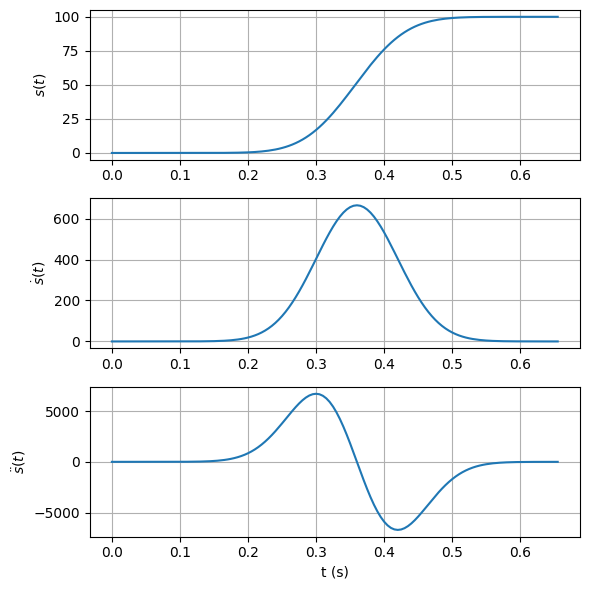

In [8]:
import numpy as np
import matplotlib.pyplot as plt

STF_dt=0.005
t = np.arange(0, t0 + 5.0 * sigma, STF_dt)

slip_rate = (
    M0
    * (1 / sigma)
    / np.sqrt(2.0 * np.pi)
    * np.exp(-0.5 * ((t - t0) / sigma)**2)
)

slip = np.cumsum(slip_rate) * STF_dt
slip_acc = np.gradient(slip_rate, STF_dt)

plt.figure(figsize=(6, 6))

plt.subplot(3, 1, 1)
plt.plot(t, slip, linewidth=1.5, color="tab:blue")
plt.ylabel("$s(t)$")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, slip_rate, linewidth=1.5, color="tab:blue")
plt.ylabel("$\\dot{s}(t)$")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, slip_acc, linewidth=1.5, color="tab:blue")
plt.ylabel("$\\ddot{s}(t)$")
plt.xlabel("t (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Crustal model

ShakerMaker solves the wavefield in a 1-D layered half-space. There are several
ways to define the model; this notebook documents two alternatives (left
commented) and then adopts the column extracted from **CRUST 1.0** at the site.

### Option 1 (commented): SCEC LOH.1 model

A two-layer model (slow layer plus half-space) from the LOH.1 benchmark. It is
left commented out because the case study uses the local column.

In [9]:
# #Initialize CrustModel (LOH1 examples)
# crust = CrustModel(2)

# #Slow layer
# vp=4.000
# vs=2.000
# rho=2.600
# Qa=10000.
# Qb=10000.
# thickness = 1.0

# crust.add_layer(thickness, vp, vs, rho, Qa, Qb)

# #Halfspace
# vp=6.000
# vs=3.464
# rho=2.700
# Qa=10000.
# Qb=10000.
# thickness = 0   #Infinite thickness!
# crust.add_layer(thickness, vp, vs, rho, Qa, Qb)

### Option 2 (commented): manual 4-layer model

A hand-defined layered model. Also left commented; kept here as a reference for
the `CrustModel(nlayers)` + `add_layer(...)` syntax.

In [10]:
# # Option 2: Manual 4-layer model (STG example)
# crust = CrustModel(4)
# vp, vs, rho, thick, Qa, Qb = 1.32, 0.75, 2.40, 0.200, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# vp, vs, rho, thick, Qa, Qb = 2.75, 1.57, 2.50, 0.800, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# vp, vs, rho, thick, Qa, Qb = 5.50, 3.14, 2.50, 14.50, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# vp, vs, rho, thick, Qa, Qb = 7.00, 4.00, 2.67, 0.000, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)


### Option 3 (used): CRUST 1.0 column at the site

The ShakerMaker-bundled CRUST 1.0 reader (`shakermaker.crust1`) is used to obtain
the local column at `(lat, lon)`. `profile_at` returns the 9-layer profile and
`print_shakermaker` prints a ready-to-paste `CrustModel` snippet. The global
topography is also plotted with the site marked.

The CRUST 1.0 citation is printed when the module is imported.

CRUST 1.0 crustal model - Laske, G., Masters, G., Ma, Z. & Pasyanos, M. (2013), Update on CRUST1.0. Data: https://igppweb.ucsd.edu/~gabi/crust1.html (obtained there and adapted for use within ShakerMaker; please cite the source).

  ----- ShakerMaker CrustModel snippet for Site 1 -----

crust = CrustModel(5)
# water - skipped (ShakerMaker FK fails with Vs=0)
# vp, vs, rho, thick, Qa, Qb = 1.50, 0.00, 1.02, 0.000, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# ice - skipped
# vp, vs, rho, thick, Qa, Qb = 3.81, 1.94, 0.92, 0.000, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# upper sediments
vp, vs, rho, thick, Qa, Qb = 2.50, 1.07, 2.11, 0.200, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# upper crystalline crust
vp, vs, rho, thick, Qa, Qb = 6.30, 3.63, 2.79, 12.620, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# middle crystalline crust
vp, vs, rho, thick, Qa, Qb = 6.60, 3.80, 2.86, 11.120, 1000.0, 1000.0
crust.add_layer(thick

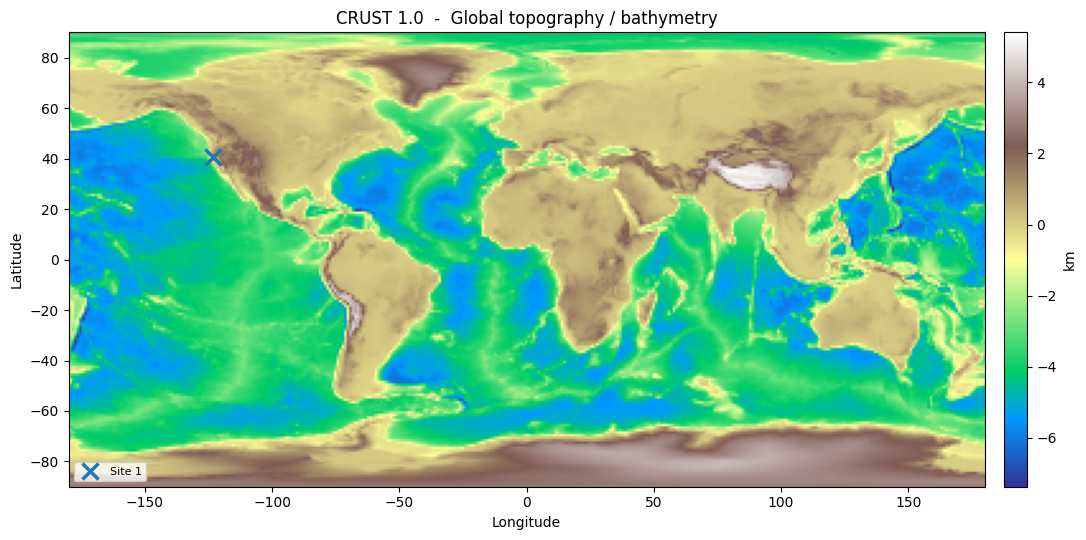

In [11]:
from shakermaker.crust1 import Crust1

crust1 = Crust1()    

lat, lon = 40.764, -123.104        
p = crust1.profile_at(lat, lon)             
crust1.print_shakermaker((lat, lon))        
# global topography with the site marked
crust1.plot_global_topo((lat, lon));

### Building the `CrustModel`

From the CRUST 1.0 column a `CrustModel(5)` is assembled: upper sediments, three
crystalline-crust layers and the mantle as the half-space (`thick = 0` denotes
infinite thickness). Water and ice are skipped because ShakerMaker does not
accept `Vs = 0`. The values are those delivered by CRUST 1.0 for the site.

In [12]:
crust = CrustModel(5)
# water - skipped (ShakerMaker FK fails with Vs=0)
# vp, vs, rho, thick, Qa, Qb = 1.50, 0.00, 1.02, 0.000, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# ice - skipped
# vp, vs, rho, thick, Qa, Qb = 3.81, 1.94, 0.92, 0.000, 1000.0, 1000.0
# crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# upper sediments
vp, vs, rho, thick, Qa, Qb = 2.50, 1.07, 2.11, 0.200, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# upper crystalline crust
vp, vs, rho, thick, Qa, Qb = 6.30, 3.63, 2.79, 12.620, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# middle crystalline crust
vp, vs, rho, thick, Qa, Qb = 6.60, 3.80, 2.86, 11.120, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# lower crystalline crust
vp, vs, rho, thick, Qa, Qb = 7.00, 3.99, 2.95, 6.310, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)
# mantle half-space
vp, vs, rho, thick, Qa, Qb = 7.93, 4.41, 3.27, 0.000, 1000.0, 1000.0
crust.add_layer(thick, vp, vs, rho, Qa, Qb)

### Visualising the crustal model

`crust.plot()` draws the layer schematic and `crust.plot_profile()` plots `Vp`,
`Vs` and `rho` against depth. This confirms the column is the expected one before
running.

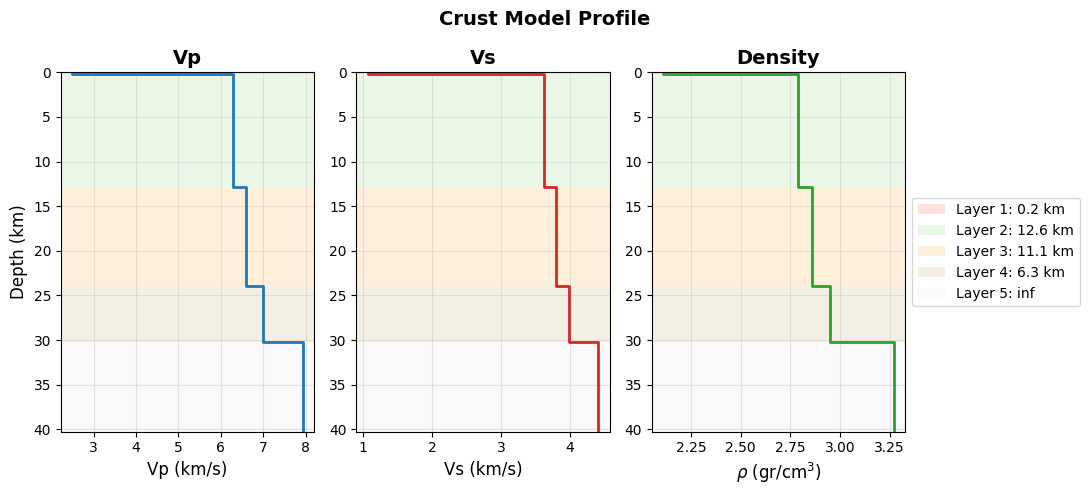

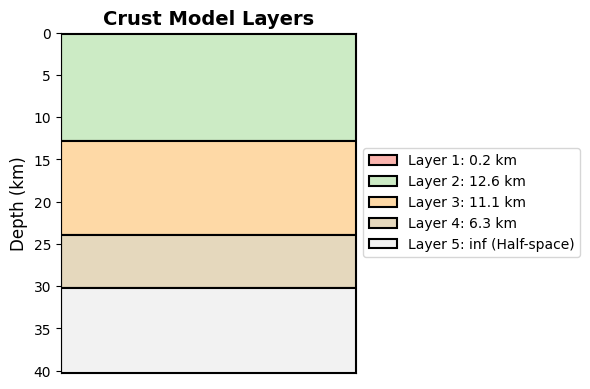

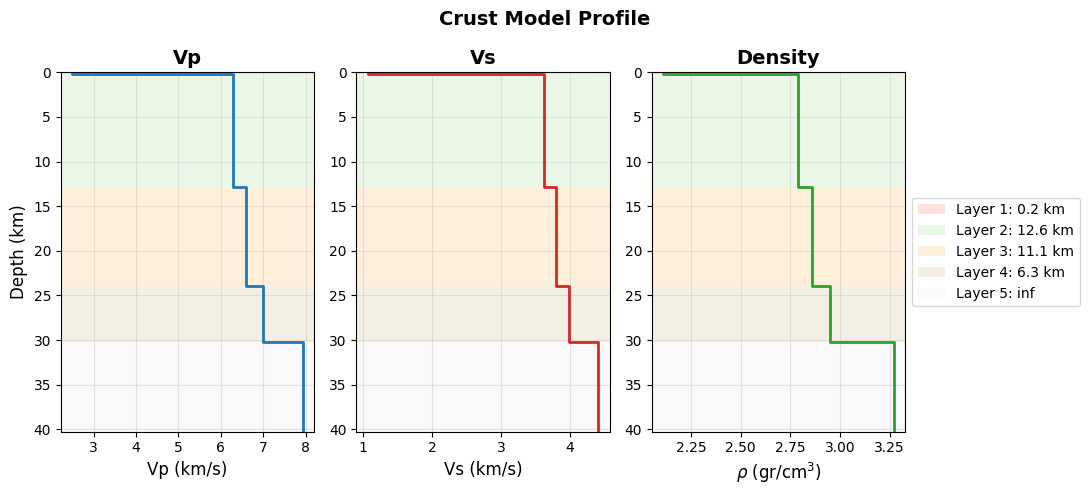

In [13]:

crust.plot()
crust.plot_profile()

## 6. Assembling the ShakerMaker model

The station list is consolidated and the `ShakerMaker` object is built, binding
the three ingredients together: crust, source and receivers. The model is now
ready for the parameter check and the run.

In [14]:
stations = StationList(station_objs, {})

model = shakermaker.ShakerMaker(crust, fault, stations)

## 7. HDF5 results writer

An HDF5 writer is defined to store the seismograms of all stations in a single
file. With the default `progressive` mode the writer flushes one station at a
time, keeping memory usage constant.

> When a writer is active the `Station` objects do not retain the time series in
> memory: the writer drains them. For that reason the stations are also saved
> individually to `.npz` further below.

In [15]:
from shakermaker.slw_extensions import HDF5StationListWriter
writer = HDF5StationListWriter("ssfi_stations.h5")

## 8. FK numerical parameters

The parameters controlling the synthesis:

- `dt` -- time step (it sets the frequency band through `f_Nyq = 1/(2 dt)`).
- `nfft` -- number of FFT points (it must hold the signal without wrap-around).
- `dk` -- wavenumber discretisation of the FK integrand.
- `tb` -- pre-arrival padding (in samples).
- `tmin`, `tmax` -- output window.

In [16]:
dt=0.005
nfft=8192 * 4      # N timesteps
dk=0.4         # wavenumber discretization
tb=400          # Initial zero-padding
tmin=0
tmax=100

### Parameter check

`check_parameters` is an arithmetic pre-check (it does not run the FK): from the
geometry and the model properties it derives the expected signal length and
recommends values for `nfft`, `dk`, `tb` and `tmax`. It also reports the usable
frequency band and a FEM mesh hint. Any `[WARN]` should be resolved before
running.

In [17]:
model.check_parameters(
    dt=0.005,
    nfft=8192 * 4,      # N timesteps
    dk=0.4,         # wavenumber discretization
    tb=400,          # Initial zero-padding
    tmin=0,
    tmax=100,
    n_per_wavelength=10,
    courant=1,
)

 ShakerMaker . PARAMETER CHECK            you set:  dt + tmax
 YOU CHOSE     dt = 0.005 s        tmax = 100 s
 GEOMETRY      r_max 91.8 km . src-rcv sep 30.0-30.0 km . Vs_min 1070 m/s
               Vp_max 7930 m/s . V_Ray 0.98 km/s
               physical signal window  t = [12.2, 103.3] s  (lasts 91.1 s)
----------------------------------------------------------------------
 dt = 0.005 s   sets your FREQUENCY BAND                       [info]
   f_Nyq         = 1/(2*dt)                   = 100 Hz       [fk.f:72]
   f_max usable  = (1-taper)*f_Nyq, taper=0.9 = 10 Hz        [fk.f:74]
   above 10 Hz   fades out smoothly, fully gone by 100 Hz    [fk.f:169]
   lambda_min    = Vs_min/f_max               = 1070/10 = 107.0 m
     element size (N=10 pts/wavelength), for YOUR mesh:
        dx <= lambda_min/N    = 107.0/10 = 10.70 m
        dt <= C*dx/Vp_surf    = 1*10.70/2500 = 0.0043 s
        (Vp_surf = Vp of the soft Vs_min layer, NOT Vp_max:
         the 10.7 m elements live in the soft su

{'passed': True,
 'recommended': {'dk': 0.4, 'tb': 400, 'nfft': 32768, 'tmax': 103.3}}

## 9. Running the simulation

The engine is run with the defined parameters and the HDF5 writer. `smth`
controls output upsampling and `sigma` the exponential damping that suppresses
wrap-around. Progress is printed to the console.

In [18]:
print("Running simulation...")
model.run(
    dt=dt,
    nfft=nfft,      # N timesteps
    dk=dk,         # wavenumber discretization
    tb=tb,          # Initial zero-padding
    tmin = tmin,    
    tmax = tmax,
    smth=1,
    sigma=2,
    verbose=True,
    showProgress=True,
    writer=writer,
)
print("Simulation complete!")

Running simulation...


ShakerMaker Run begin. dt=0.005 nfft=32768 dk=0.4 tb=400 tmin=0 tmax=100
------------------------------------------------------------------------
rank=0 nprocs=1 ipair=0 skip_pairs=1 npairs=1 !!
calling core START
_call_core
        psource.x = [4512.5645625  491.2223167   30.       ]
        station.x = [np.float64(4519.5333956), np.float64(399.6424017), 0.0]
ShakerMaker._call_core - calling core.subgreen
	mb: 6
	src: 5
	rcv: 1
	styoe: 2
	updn: 0
	d: [ 0.2  12.62 11.12  6.06  0.25  0.  ]
	a: [2.5  6.3  6.6  7.   7.   7.93]
	b: [1.07 3.63 3.8  3.99 3.99 4.41]
	rho: [2.11 2.79 2.86 2.95 2.95 3.27]
	qa: [1000. 1000. 1000. 1000. 1000. 1000.]
	qb: [1000. 1000. 1000. 1000. 1000. 1000.]
	dt: 0.005
	nfft: 32768
	tb: 400
	nx: 1
	sigma: 2
	smth: 1
	wc1: 1
	wc2: 2
	pmin: 0
	pmax: 1
	dk: 0.4
	kc: 15.0
	taper: 0.9
	x: 91.84468120791152
	pf: 5.934119456780721
	df: 0.3490658503988659
	lf: 0.0
	sx: 4512.5645625
	sy: 491.2223167
	rx: 4519.5333956
	ry: 399.6424017
	
calling core

## 10. Saving the stations (`.npz`)

As a backup independent of the HDF5 file, each station is saved to a `.npz` file
named after it. A station can then be reloaded later without recomputing, via
`Station().load(...)`. (Recall that with an active writer the series are not kept
in the object; this save works because the station objects were retained when the
list was assembled.)

In [19]:
for s in station_objs:
    name = s._metadata["name"]
    s.save(f"{name}.npz") 

## 11. Retrieving and plotting the displacement

Station 0 is retrieved together with its three displacement components `(z, e, n)`
and their time vector. The three components are plotted in separate subplots over
the window `[0, tmax]`.

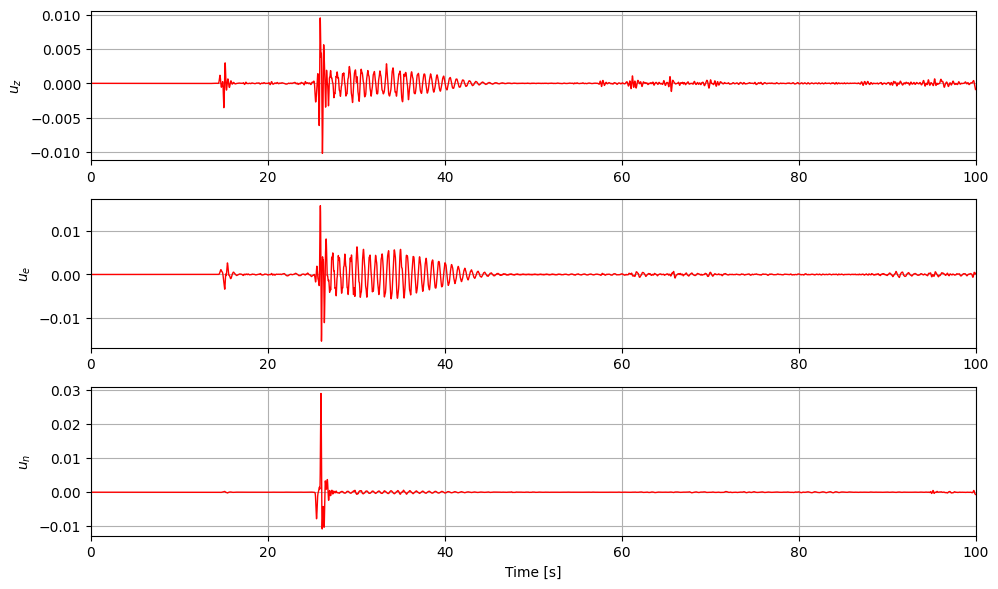

In [20]:
sta = stations.get_station_by_id(0)

z_shaker, e_shaker, n_shaker, t_shaker = sta.get_response()

plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t_shaker, z_shaker, "r", linewidth=1)
plt.xlim([0,100])
plt.ylabel(r"$u_z$")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t_shaker, e_shaker, "r", linewidth=1)
plt.xlim([0,100])
plt.ylabel(r"$u_e$")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t_shaker, n_shaker, "r", linewidth=1)
plt.xlim([0,100])
plt.ylabel(r"$u_n$")
plt.xlabel("Time [s]")
plt.grid()

plt.tight_layout()
plt.show()


## 12. Velocity -> displacement / acceleration conversion

A helper to derive displacement and acceleration from the velocity series:

- displacement: numerical integration (cumulative trapezoidal rule).
- acceleration: backward finite difference.

It is kept as an explicit function so the post-processing remains transparent.

In [21]:
from scipy.integrate import cumulative_trapezoid

def vel_to_disp_acel(z_v,e_v,n_v,t ):
    z_d = cumulative_trapezoid(z_v.copy(), t, initial=0.)
    e_d = cumulative_trapezoid(e_v.copy(), t, initial=0.)
    n_d = cumulative_trapezoid(n_v.copy(), t, initial=0.)
    Nt = len(t)
    dt = t[1] - t[0]
    print(f"dt = {dt}")
    z_a = np.zeros(Nt)
    z_a[1:] = (z_v[1:] - z_v[0:-1])/dt
    e_a = np.zeros(Nt)
    e_a[1:] = (e_v[1:] - e_v[0:-1])/dt
    n_a = np.zeros(Nt)
    n_a[1:] = (n_v[1:] - n_v[0:-1])/dt
    return z_d, e_d , n_d , z_a, e_a, n_a

### Applying the conversion

The conversions are applied to the three components of the station, yielding
displacements (`*_d`) and accelerations (`*_a`).

In [22]:
z_d_shaker, e_d_shaker , n_d_shaker , z_a_shaker, e_a_shaker, n_a_shaker= vel_to_disp_acel(z_shaker, e_shaker, n_shaker, t_shaker   )

dt = 0.005000000000000782


### Acceleration plot

The three acceleration components are plotted. These are the series used to build
the response spectrum in the next block.

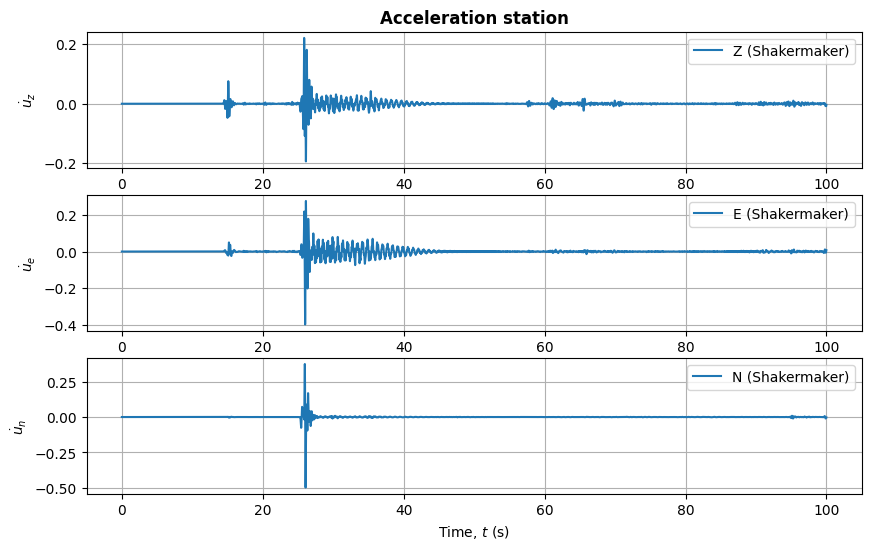

In [23]:

plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.title("Acceleration station", fontweight='bold')
plt.plot(t_shaker, z_a_shaker, label="Z (Shakermaker)")
plt.xlabel("Time [s]")
plt.ylabel(r"$\dot{u}_z$")
# plt.xlim([0,80])
plt.grid()
plt.legend()

plt.subplot(3,1,2)
plt.plot(t_shaker, e_a_shaker, label="E (Shakermaker)")
plt.ylabel(r"$\dot{u}_e$")
# plt.xlim([0,80])
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(t_shaker, n_a_shaker, label="N (Shakermaker)")
plt.ylabel(r"$\dot{u}_n$")
plt.xlabel(r"Time, $t$ (s)")
# plt.xlim([0,80])
plt.grid()
plt.legend()

plt.show()

## 13. Response spectrum (Newmark SDOF)

A response-spectrum analyser built on direct integration of the
single-degree-of-freedom oscillator with the Newmark method (`gamma = 1/2`,
`beta = 1/4`, i.e. the constant-average-acceleration scheme).

- `solve_newmark` integrates an oscillator of period `Tj` and damping `zeta`
  under the ground acceleration `ag`, and returns the maxima `Sd, Sv, Sa` and
  the pseudo-values `PSv, PSa`.
- `NewmarkSpectrumAnalyzer.compute` sweeps the periods and assembles the
  spectrum; it also keeps the oscillator history at `T = 1 s` for inspection.

Input accelerations are interpreted in `g` (multiplied by `9.81`) and the spectra
are returned normalised to `g`.

In [24]:
import numpy as np
from scipy.integrate import cumulative_trapezoid  # noqa: F401
from numba import njit


@njit
def solve_newmark(ag, dt, zeta, Tj):
    gama = 1/2
    beta = 1/4
    w = 2 * np.pi / Tj
    m = 1.0
    k = m * w**2
    c = 2 * m * w * zeta
    a1 = m / (beta * dt ** 2) + c * gama / (beta * dt)
    a2 = m / (beta * dt) + c * (gama / beta - 1)
    a3 = m * (1 / (2 * beta) - 1) + c * dt * (gama / (2 * beta) - 1)
    kp = k + a1

    u = np.zeros(len(ag))
    v = np.zeros(len(ag))
    a = np.zeros(len(ag))
    at = np.zeros(len(ag))

    for i in range(len(ag) - 1):
        p_eff = -m * ag[i] + a1 * u[i] + a2 * v[i] + a3 * a[i]
        u[i + 1] = p_eff / kp
        a[i + 1] = (u[i + 1] - u[i]) / (beta * dt ** 2) - v[i] / (beta * dt) - a[i] * (1 / (2 * beta) - 1)
        at[i + 1] = a[i + 1] + ag[i]
        v[i + 1] = v[i] + dt * ((1 - gama) * a[i] + gama * a[i + 1])

    Sd = np.max(np.abs(u))
    Sv = np.max(np.abs(v))
    Sa = np.max(np.abs(at))
    PSv = w * Sd
    PSa = w ** 2 * Sd

    return Sd, Sv, Sa, PSv, PSa, u, v, a, at


class NewmarkSpectrumAnalyzer:

    @staticmethod
    def compute(ag, dt, zeta=0.05, max_period=5.01, intervals=0.01):
        T = np.arange(0.0, max_period, intervals)
        ag = np.asarray(ag) * 9.81

        Sd, Sv, Sa, PSv, PSa = [], [], [], [], []
        u_hist, v_hist, a_hist, at_hist = [], [], [], []

        gama = 1/2
        beta = 1/4
        q = dt * np.pi * np.sqrt(2) * np.sqrt(gama - 2 * beta)

        for Tj in T:
            if Tj > q:
                Sd_, Sv_, Sa_, PSv_, PSa_, u, v, a, at = solve_newmark(ag, dt, zeta, Tj)
                Sd.append(Sd_)
                Sv.append(Sv_)
                Sa.append(Sa_)
                PSv.append(PSv_)
                PSa.append(PSa_)

                if np.isclose(Tj, 1.0, atol=0.01):
                    u_hist = u
                    v_hist = v
                    a_hist = a
                    at_hist = at
            else:
                PGA = np.max(np.abs(ag))
                Sd.append(0)
                Sv.append(0)
                Sa.append(PGA)
                PSv.append(0)
                PSa.append(PGA)

        Sd = np.array(Sd)
        Sv = np.array(Sv)
        Sa = np.array(Sa) / 9.81
        PSv = np.array(PSv)
        PSa = np.array(PSa) / 9.81
        a_hist = np.array(a_hist) / 9.81
        at_hist = np.array(at_hist) / 9.81

        return {
            'T': T,
            'PSa': PSa,
            'PSv': PSv,
            'Sd': Sd,
            'Sv': Sv,
            'Sa': Sa,
            'u': np.array(u_hist),
            'v': np.array(v_hist),
            'a': a_hist,
            'at': at_hist
        }

### Computing and plotting the response spectrum

The pseudo-acceleration spectrum `PSa` is computed for the three components and
plotted against period. This is the final deliverable: the seismic demand of the
synthesised site, ready to compare against reference records or to feed a
structural analysis.

---

*Notebook documented from `example.ipynb`. The code is identical to the original;
only markdown headings and explanations have been added.*


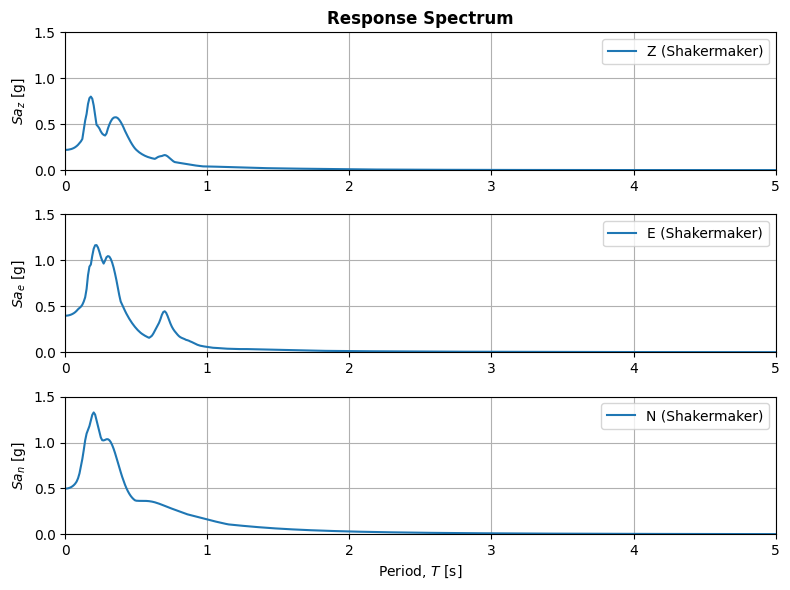

In [25]:
res_z = NewmarkSpectrumAnalyzer.compute(z_a_shaker, dt)
res_e = NewmarkSpectrumAnalyzer.compute(e_a_shaker, dt)
res_n = NewmarkSpectrumAnalyzer.compute(n_a_shaker, dt)

T = res_z['T']
Sa_z, Sa_e, Sa_n = res_z['PSa'], res_e['PSa'], res_n['PSa']

plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.title("Response Spectrum", fontweight='bold')
plt.plot(T, Sa_z, label="Z (Shakermaker)")
plt.ylabel(r"$Sa_z$ [g]")
plt.ylim([0, 1.5])
plt.xlim([0,5])
plt.grid()
plt.legend()

plt.subplot(3,1,2)
plt.plot(T, Sa_e, label="E (Shakermaker)")
plt.ylabel(r"$Sa_e$ [g]")
plt.ylim([0, 1.5])
plt.xlim([0,5])
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(T, Sa_n, label="N (Shakermaker)")
plt.ylabel(r"$Sa_n$ [g]")
plt.ylim([0, 1.5])
plt.xlim([0,5])
plt.xlabel(r"Period, $T$ [s]")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()